In [23]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy import stats
import regions
from grid_strategy import strategies
import pylab as pl
sqgrid = strategies.SquareStrategy()
basepath = '/orange/adamginsburg/jwst/w51/'
filternames =all_filternames = ['F140M', 'F162M', 'F182M', 'F187N', 'F210M', 'F335M', 'F360M', 'F405N', 'F410M', 'F480M', 'F560W', 'F770W', 'F1000W', 'F1280W', 'F2100W']
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}



tables_per_filters ={'f140m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f162m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f182m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f187n': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f210m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f335m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f360m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f405n': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f410m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f480m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f560w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f560w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f770w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f770w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f1000w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1000w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f1280w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1280w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f2100w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f2100w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits'}

def xmatch_plot(basetable, ref_filter='f140m', filternames=filternames,
                maxsep=0.13*u.arcsec, obsid='001', sel=None, axlims=[-0.5, 0.5, -0.5, 0.5],
                alpha=0.01,
                regs=['brick_nrca.reg', 'brick_nrcb.reg']):
    statsd = {}
    fig1 = pl.figure(1)
    fig2 = pl.figure(2)

    if sel is None:
        sel = np.ones(len(basetable), dtype='bool')
    basetable = basetable[sel]

    basecrds = basetable[f'skycoord_{ref_filter}']

    refhdr = fits.getheader(image_filenames[ref_filter], ext=('SCI', 1))
    refwcs = WCS(refhdr)

    gridspec = sqgrid.get_grid(len(filternames)-1)
    ii = 0

    for filtername in filternames:
        if filtername == ref_filter:
            continue
        ax = fig1.add_subplot(gridspec[ii])

        # only include detections
        thissel = ~basetable[f'flux_fit_{filtername.lower()}'].mask

        crds = basetable[f'skycoord_{filtername.lower()}'][thissel]
        radiff = (crds.ra-basecrds.ra[thissel]).to(u.arcsec)
        decdiff = (crds.dec-basecrds.dec[thissel]).to(u.arcsec)

        sep = basetable[f'sep_{filtername.lower()}'][thissel].quantity.to(u.arcsec)

        # sep = 0 implies it's matched to itself
        ok = (sep < maxsep) & (sep > 0)
        print(f"For filter {filtername}, found {ok.sum()} out of {len(ok)} data points")

        ax.scatter(radiff, decdiff, marker=',', s=1, alpha=alpha)
        if regs is None:
            ax.scatter(radiff[ok], decdiff[ok], marker=',', s=1, alpha=alpha)
        else:
            for reg in regs:
                reg = regions.Regions.read(f'{basepath}/regions_/{reg}')[0]
                match = reg.contains(crds, refwcs)
                ax.scatter(radiff[ok & match], decdiff[ok & match], marker=',', s=1, alpha=alpha)

        ax.axis(axlims)
        ax.set_title(filtername)

        ax2 = fig2.add_subplot(gridspec[ii])
        ax2.hist(sep.to(u.arcsec).value, bins=np.linspace(0, maxsep.to(u.arcsec).value))
        #ax2.set_xlabel("Separation (\")")
        ax2.set_title(filtername)

        print(f"med sep: {np.median(sep)}, std(sep): {np.std(sep)}")
        statsd[filtername] = {
            'med': np.median(sep),
            'mad': stats.mad_std(sep.copy()),
            'std': np.std(sep),
            'med_thr': np.median(sep[ok]),
            'mad_thr': stats.mad_std(sep[ok]),
            'std_thr': np.std(sep[ok]),
            '10pct': np.percentile(sep, 10),
            '1pct': np.percentile(sep, 1),
            '0.1pct': np.percentile(sep, 0.1),
            '90pct': np.percentile(sep, 90),
            '99pct': np.percentile(sep, 99),
            '99.9pct': np.percentile(sep, 99.9),
        }
        ii+=1

    fig1.supxlabel("RA Offset (\")")
    fig1.supylabel("Dec Offset (\")")
    fig2.supxlabel("Offset (\")")
    fig1.tight_layout()
    fig2.tight_layout()
    return statsd

['skycoord_ra', 'skycoord_dec', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'qfit_f140m', 'cfit_f140m', 'sharpness_f140m', 'roundness1_f140m', 'roundness2_f140m', 'from_sat_catalog_f140m', 'skycoord_f480m', 'flux_fit_f480m', 'flux_err_f480m', 'nmatch_f480m', 'nmatch_good_f480m', 'qfit_f480m', 'cfit_f480m', 'sharpness_f480m', 'roundness1_f480m', 'roundness2_f480m', 'from_sat_catalog_f480m', 'skycoord_f560w', 'flux_fit_f560w', 'flux_err_f560w', 'nmatch_f560w', 'nmatch_good_f560w', 'qfit_f560w', 'cfit_f560w', 'sharpness_f560w', 'roundness1_f560w', 'roundness2_f560w', 'from_sat_catalog_f560w', 'skycoord_f770w', 'flux_fit_f770w', 'flux_err_f770w', 'nmatch_f770w', 'nmatch_good_f770w', 'qfit_f770w', 'cfit_f770w', 'sharpness_f770w', 'roundness1_f770w', 'roundness2_f770w', 'from_sat_catalog_f770w', 'skycoord_f1000w', 'flux_fit_f1000w', 'flux_err_f1000w', 'nmatch_f1000w', 'nmatch_good_f1000w', 'qfit_f1000w', 'cfit_f1000w', 'sharpness_f1000w', 'round

KeyError: 'sep_f140m'

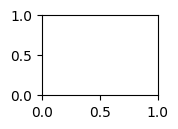

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [24]:
from astropy.table import Table

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
sel = catalog['nmatch_band'] > 3
print(catalog.colnames)
xmatch_plot(catalog, sel=sel, axlims=[-0.15, 0.15, -0.15, 0.15]);
